# Explore anomaly scores

In [34]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [35]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from anomaly.utils import specobjid_to_idx
from autoencoders.ae import AutoEncoder
from sdss.metadata import MetaData

meta = MetaData()

# Constants

In [2]:
mse_cols = ['mse', 'mse_97', 'mse_filter_250', 'mse_filter_250_97']
mse_rel_cols = ['mse_rel', 'mse_97_rel', 'mse_filter_250_rel', 'mse_filter_250_97_rel']

# Custom functions

In [3]:
def scores_arr_to_df(score_paths, bin_idx_to_specobjid):

    score_names = [score.split("/")[-1][:-4] for score in score_paths]
    objids_bin = bin_idx_to_specobjid[:, 1]

    scores_dict = {}

    for score_name, score_path in zip(score_names, score_paths):

        scores_dict[score_name] = np.load(score_path)[:, 0]

    scores_df = pd.DataFrame(data=scores_dict, index=objids_bin)
    scores_df.index.name = 'specobjid'
    scores_df.sort_values(by='mse', ascending=False, inplace=True)

    return scores_df[mse_cols + mse_rel_cols]


# Directories

In [36]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
bin_ids = [f"bin_{i:02d}" for i in range(4)]
#
ch_4_dir = f"{thesis_dir}/chapters/04_figures"

# Data

In [31]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_03 = np.load(
    f"{spectra_dir}/bin_03/bin_03_index_specobjid.npy"
)

# Model

In [37]:
ae_03 = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/bin_03/winner",
)

# Build csv with scores for each bin

```python
bin_id = 'bin_03'

score_paths = glob.glob(f"{scores_dir}/{bin_id}/*.npy")

bin_idx_to_specobjid = np.load(
    f"{spectra_dir}/"
    f"{bin_id}/{bin_id}_index_specobjid.npy"
)

scores_df = scores_arr_to_df(score_paths, bin_idx_to_specobjid)
scores_df.to_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index=True
)
```

```python
for bin_id in bin_ids:

    score_paths = glob.glob(f"{scores_dir}/{bin_id}/*.npy")

    bin_idx_to_specobjid = np.load(
        f"{spectra_dir}/"
        f"{bin_id}/{bin_id}_index_specobjid.npy"
    )

    scores_df = scores_arr_to_df(score_paths, bin_idx_to_specobjid)
    scores_df.to_csv(
        f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
        index=True
    )
```

## Bind 03

In [7]:
bin_id = 'bin_03'
score_03_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)

In [8]:
score_03_df.loc[1945689783355336704]

mse                      17.067748
mse_97                   15.249345
mse_filter_250           16.994252
mse_filter_250_97        15.183400
mse_rel                  16.630739
mse_97_rel               15.008672
mse_filter_250_rel       16.562386
mse_filter_250_97_rel    14.942477
Name: 1945689783355336704, dtype: float64

In [19]:
n_spec = score_03_df.shape[0]
n_tops = [int(n_spec*p) for p in [0.001, 0.005, 0.01, 0.05]]
n_tops_perc = [f'{n/n_spec*100:.2f}%' for n in n_tops]

In [20]:
n_tops, n_tops_perc

([181, 909, 1818, 9092], ['0.10%', '0.50%', '1.00%', '5.00%'])

# Illustration of scores

In [47]:
bad_specobjid = 531492683672217600
idx_bad = specobjid_to_idx(bad_specobjid, idx_id_03)
spec_bad = spectra[idx_bad]
spec_bad_rec = ae_03.reconstruct(spec_bad).reshape(-1)
residual_bad = np.sqrt(np.abs(spec_bad**2 - spec_bad_rec**2))
# -------------------------------------------------
broad_specobjid = 1924292192684238848
idx_broad = specobjid_to_idx(broad_specobjid, idx_id_03)
spec_broad = spectra[idx_broad]
spec_broad_rec = ae_03.reconstruct(spec_broad).reshape(-1)
residual_broad = np.sqrt(np.abs(spec_broad**2-spec_broad_rec**2))
# -------------------------------------------------
score_03_df.loc[[bad_rec_specobjid, broad_anomaly_specobjid]]

,mse,mse_97,mse_filter_250,mse_filter_250_97,mse_rel,mse_97_rel,mse_filter_250_rel,mse_filter_250_97_rel
specobjid,,,,,,,,
531492683672217600,29.718512,26.180044,29.422013,26.051243,28.066405,26.032973,27.933711,25.945725
1924292192684238848,44.160318,15.315991,41.574367,15.108849,21.568775,13.925405,20.861547,13.805299


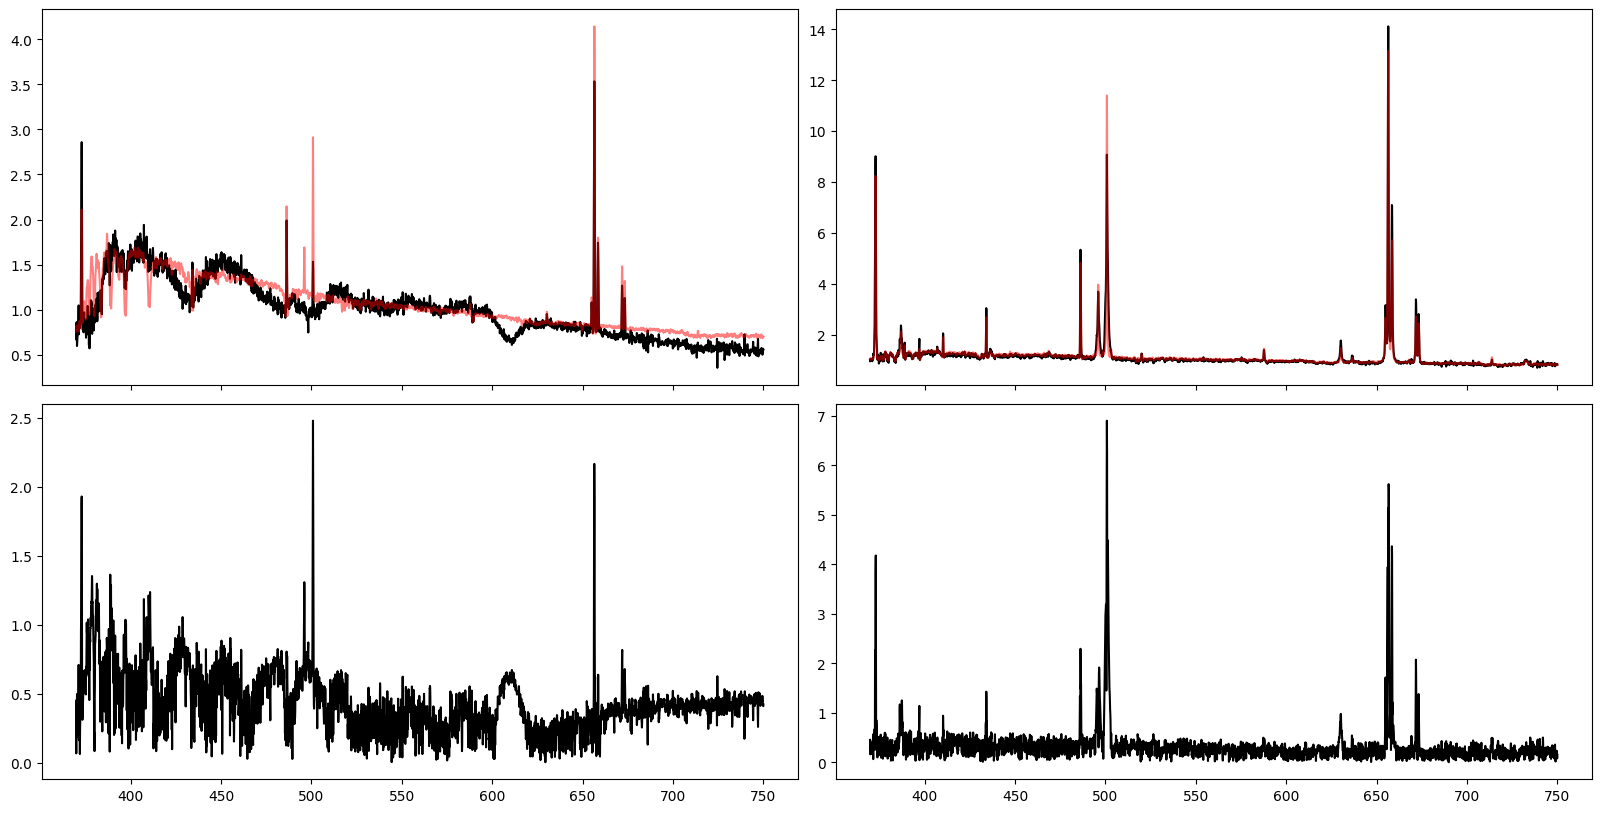

In [49]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 10)
)
# ----------------------------------------------------
axs[0, 0].plot(wave_nm, spec_bad, color='black')
axs[0, 0].plot(wave_nm, spec_bad_rec, color='red', alpha=0.5)
# ----------------------------------------------------
axs[1, 0].plot(wave_nm, residual_bad, color='black')
# ----------------------------------------------------
axs[0, 1].plot(wave_nm, spec_broad, color='black')
axs[0, 1].plot(wave_nm, spec_broad_rec, color='red', alpha=0.5)
# ----------------------------------------------------
axs[1, 1].plot(wave_nm, residual_broad, color='black')

# 
plt.subplots_adjust(hspace=0.05, wspace=0.05)

# Median Specs

## MSE

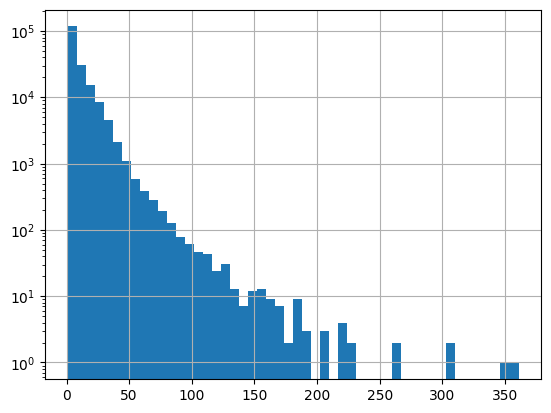

In [24]:
score_03_df.mse.hist(bins=50)
plt.yscale('log')